In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, r2_score, f1_score, confusion_matrix,recall_score

In [9]:
df= pd.read_csv("fake_job_postings.csv")

In [10]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [12]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

([<matplotlib.patches.Wedge at 0x277f4728d70>,
 [Text(-1.0872906101063062, 0.16673070855321376, '0'),
  Text(1.0872905849306571, -0.16673087272952639, '1')],
 [Text(-0.5930676055125306, 0.0909440228472075, '95.2%'),
  Text(0.5930675917803584, -0.09094411239792347, '4.8%')])

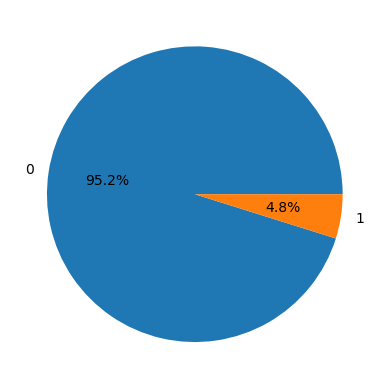

In [13]:
classes_count=df["fraudulent"].value_counts()
plt.pie(classes_count, labels=["0", "1"],autopct="%1.1f%%")

In [14]:
text_cols=['title', 'description', 'requirements', 'company_profile', 'benefits']
df[text_cols]=df[text_cols].fillna('')
df['combined_text']=(df['title']+''+
                     df['description']+''+
                     df['requirements']+''+
                     df['company_profile']+''+
                     df['benefits'])
df['combined_text'].head()
                     


0    Marketing InternFood52, a fast-growing, James ...
1    Customer Service - Cloud Video ProductionOrgan...
2    Commissioning Machinery Assistant (CMA)Our cli...
3    Account Executive - Washington DCTHE COMPANY: ...
4    Bill Review ManagerJOB TITLE: Itemization Revi...
Name: combined_text, dtype: object

In [15]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile            0
description                0
requirements               0
benefits                   0
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
combined_text              0
dtype: int64

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=5000, stop_words='english')
X=tfidf.fit_transform(df['combined_text'])
y=df['fraudulent']
print(X.shape)
print(y.shape)

(17880, 5000)
(17880,)


In [17]:
print(df['fraudulent'].value_counts())
print(df['fraudulent'].value_counts(normalize=True))

fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    0.951566
1    0.048434
Name: proportion, dtype: float64


In [18]:
from sklearn.metrics import recall_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

In [19]:
X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=42, test_size=0.2)

In [20]:
models={'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
       'Decision Tree':DecisionTreeClassifier(class_weight='balanced'),
       'SVM':LinearSVC(class_weight='balanced',max_iter=1000),
       'Random Forest':RandomForestClassifier(class_weight='balanced', n_estimators=100),
       'GradientBoostingClassifier':GradientBoostingClassifier(n_estimators=100),
       'xgb':xgb.XGBClassifier(scale_pos_weight=20, n_estimators=100, eval_metric='logloss'),
       'naive_bayes':MultinomialNB()
      }
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    recall=recall_score(y_test, y_pred)
    cr=classification_report(y_test, y_pred)
    print(f"for model {name} =recall= {recall}")
    print(f"for model {name} =cr= {cr}")

for model Logistic Regression =recall= 0.8674033149171271
for model Logistic Regression =cr=               precision    recall  f1-score   support

           0       0.99      0.97      0.98      3395
           1       0.59      0.87      0.71       181

    accuracy                           0.96      3576
   macro avg       0.79      0.92      0.84      3576
weighted avg       0.97      0.96      0.97      3576

for model Decision Tree =recall= 0.6298342541436464
for model Decision Tree =cr=               precision    recall  f1-score   support

           0       0.98      0.97      0.98      3395
           1       0.57      0.63      0.60       181

    accuracy                           0.96      3576
   macro avg       0.78      0.80      0.79      3576
weighted avg       0.96      0.96      0.96      3576

for model SVM =recall= 0.7900552486187845
for model SVM =cr=               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3395
  

In [21]:
model=DecisionTreeClassifier(class_weight='balanced', max_depth=4)
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
print(recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
   

0.8453038674033149
              precision    recall  f1-score   support

           0       0.98      0.54      0.70      3395
           1       0.09      0.85      0.16       181

    accuracy                           0.56      3576
   macro avg       0.54      0.69      0.43      3576
weighted avg       0.94      0.56      0.67      3576



In [22]:
model=xgb.XGBClassifier(scale_pos_weight=25, 
              n_estimators=200,
              max_depth=6,
              eval_metric='logloss')
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
print(recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7513812154696132
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3395
           1       0.92      0.75      0.83       181

    accuracy                           0.98      3576
   macro avg       0.95      0.87      0.91      3576
weighted avg       0.98      0.98      0.98      3576



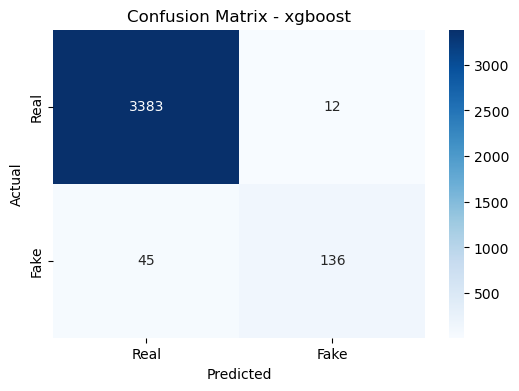

In [23]:
import seaborn as sns
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - xgboost")
plt.show()
    

In [24]:
from sklearn.model_selection import GridSearchCV

#Logistic Regression
lr_params={
    "C":[0.01, 0.1, 1, 10, 100]
}
lr=LogisticRegression(class_weight='balanced', max_iter=1000)
lr_grid_search=GridSearchCV(lr, lr_params, scoring="recall", cv=5,n_jobs=-1)

lr_grid_search.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [25]:
print("Best LR params:", lr_grid_search.best_params_)
print("Best Lr score:", lr_grid_search.best_score_)

Best LR params: {'C': 1}
Best Lr score: 0.8554744525547445


In [26]:
#svc

svc_params={
    "C":[0.01, 0.1, 1, 10, 100]
}
svc=LinearSVC(class_weight='balanced', max_iter=5000)
svc_grid_search=GridSearchCV(svc, svc_params, scoring="recall", cv=5,n_jobs=-1)

svc_grid_search.fit(X_train, y_train)

,estimator,LinearSVC(cla...max_iter=5000)
,param_grid,"{'C': [0.01, 0.1, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [27]:
print("Best SVC params:", svc_grid_search.best_params_)
print("Best SVC Score:", svc_grid_search.best_score_)

Best SVC params: {'C': 0.1}
Best SVC Score: 0.8598540145985402


In [28]:
y_pred_test=lr_grid_search.predict(X_test)
y_pred_train=lr_grid_search.predict(X_train)

In [29]:
print("LR cr:", classification_report(y_test, y_pred_test))
print("LR cr:", classification_report(y_train, y_pred_train))

LR cr:               precision    recall  f1-score   support

           0       0.99      0.97      0.98      3395
           1       0.59      0.87      0.71       181

    accuracy                           0.96      3576
   macro avg       0.79      0.92      0.84      3576
weighted avg       0.97      0.96      0.97      3576

LR cr:               precision    recall  f1-score   support

           0       1.00      0.97      0.99     13619
           1       0.65      1.00      0.79       685

    accuracy                           0.97     14304
   macro avg       0.82      0.98      0.89     14304
weighted avg       0.98      0.97      0.98     14304



In [30]:
y_pred=svc_grid_search.predict(X_test)

In [31]:
print("svc cr:", classification_report(y_test, y_pred))

svc cr:               precision    recall  f1-score   support

           0       0.99      0.97      0.98      3395
           1       0.63      0.85      0.72       181

    accuracy                           0.97      3576
   macro avg       0.81      0.91      0.85      3576
weighted avg       0.97      0.97      0.97      3576



In [32]:
y_pred__test=svc_grid_search.predict(X_test)
y_pred__train=svc_grid_search.predict(X_train)

In [33]:
print("svc cr:", classification_report(y_test, y_pred__test))
print("svc cr:", classification_report(y_train, y_pred__train))

svc cr:               precision    recall  f1-score   support

           0       0.99      0.97      0.98      3395
           1       0.63      0.85      0.72       181

    accuracy                           0.97      3576
   macro avg       0.81      0.91      0.85      3576
weighted avg       0.97      0.97      0.97      3576

svc cr:               precision    recall  f1-score   support

           0       1.00      0.98      0.99     13619
           1       0.70      1.00      0.82       685

    accuracy                           0.98     14304
   macro avg       0.85      0.99      0.90     14304
weighted avg       0.99      0.98      0.98     14304



In [34]:
print("confusion matrix:", confusion_matrix(y_test, y_pred_test))

confusion matrix: [[3288  107]
 [  24  157]]


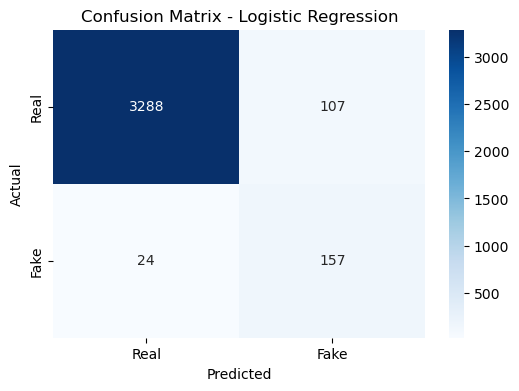

In [42]:
import seaborn as sns
cm=confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
    

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score


lr_pred = lr_grid_search.predict(X_test)

lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

# SVC
svc_pred = svc_grid_search.predict(X_test)

svc_precision = precision_score(y_test, svc_pred)
svc_recall = recall_score(y_test, svc_pred)
svc_f1 = f1_score(y_test, svc_pred)


In [37]:
xgb_clf=xgb.XGBClassifier(scale_pos_weight=20, n_estimators=100, eval_metric='logloss')

In [38]:
xgb_clf.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [39]:
xgb_y_pred=xgb_clf.predict(X_test)

In [40]:
xgb_precision=precision_score(y_test, xgb_y_pred)
xgb_recall=recall_score(y_test, xgb_y_pred)
xgb_f1=f1_score(y_test, xgb_y_pred)

In [41]:
from sklearn.model_selection import RandomizedSearchCV

#xgb
xgb_params={
    'n_estimators':[10,15,25,100],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],

}

xgb_clf=xgb.XGBClassifier(random_state=42,eval_metric='logloss')

xgb_search=RandomizedSearchCV(estimator=xgb_clf,param_distributions=xgb_params,n_iter=10,scoring='recall', cv=5,n_jobs=-1,random_state=42)


xgb_search.fit(X_train, y_train)

print("Best Parameters:", xgb_search.best_params_)
print("Best Recall:", xgb_search.best_score_)

Best Parameters: {'n_estimators': 25, 'max_depth': 7, 'learning_rate': 0.2}
Best Recall: 0.545985401459854


In [44]:
xgb_pred= xgb_search.predict(X_test)



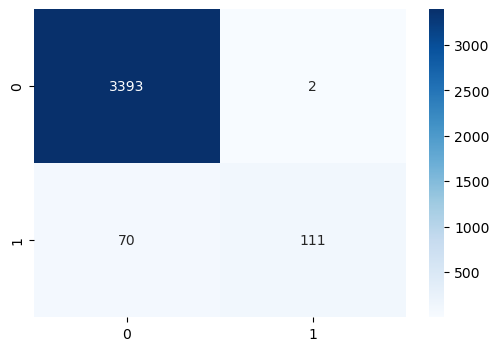

In [45]:
import seaborn as sns
cm= confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.show()

# import seaborn as sns
# cm=confusion_matrix(y_test, lr_pred)

# plt.figure(figsize=(6,4))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt='d',
#     cmap='Blues',
#     xticklabels=['Real', 'Fake'],
#     yticklabels=['Real', 'Fake']
# )

# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix - Logistic Regression")
# plt.show()
    

In [46]:
print("recall:", recall_score(y_test, xgb_pred))
print("f1:", f1_score(y_test, xgb_pred))
print("precision:", precision_score(y_test, xgb_pred))


      

recall: 0.6132596685082873
f1: 0.7551020408163265
precision: 0.9823008849557522


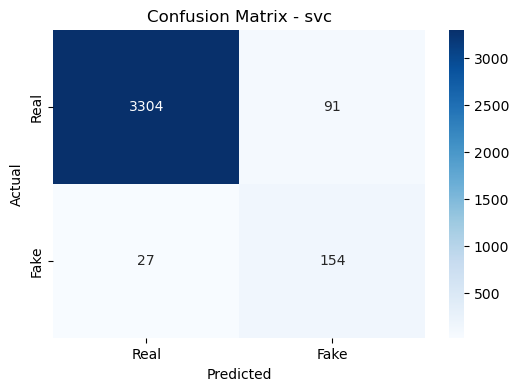

In [47]:
cm=confusion_matrix(y_test, svc_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - svc")
plt.show()

In [48]:
import pandas as pd

comparision=pd.DataFrame({"Model":["Logistic regression", "SVC", "XGBoost"],
                          "Precision":[lr_precision,svc_precision,xgb_precision],
                          "Recall": [lr_recall, svc_recall, xgb_recall],
                          "F1 Score": [lr_f1, svc_f1, xgb_f1]
})
comparision

,Model,Precision,Recall,F1 Score
0,Logistic regression,0.594697,0.867403,0.705618
1,SVC,0.628571,0.850829,0.723005
2,XGBoost,0.866242,0.751381,0.804734


In [49]:
import joblib

best_lr = lr_grid_search.best_estimator_
joblib.dump(best_lr, "lr_model.pkl")
print("Saved!")

Saved!
